# Unsupervised Learning - Gözetimsiz Öğrenme

Bağımlı değişkenin elimizde olmadığı durumlarda gözlem birimlerinin bu duruma uygun olarak bir şekilde anlamlı hale getirilme çabasıdır. 

Burada kullanılan yöntemler şu şekildedir:
* K-Means
* Hiyerarşik Kümeleme Analizi
* Temel Bileşen Analizi

Bu yöntemler bize, elimizde bağımlı değişkenler olmadığında bağımsız değişkenler ile nasıl işlemler yapabileceğimizi anlatırlar.

# K-Means (K - Ortalamaları)

Amaç: Gözlemleri, birimlerine olan benzerliklerine göre kümelere ayırmaktır.

Kümeleme yöntemlerinde, benzerlik matrislerini kullanarak, çeşitli uzaklık hesaplamaları yaparak, gözlemler ya da değişkenler kümelenmeye çalışılmaktadır. Oluşturulan kümelerin kendi içerilerinde homojen, birbirlerine göre heterojen olmaları istenir. Kümeleme yöntemleri hiyerarşik ve hiyerarşik olmayan kümeleme yöntemleri diye 2'ye ayrılır. 

K-Means Yöntemi ise bir hiyerarşik olmayan kümeleme yöntemidir. 

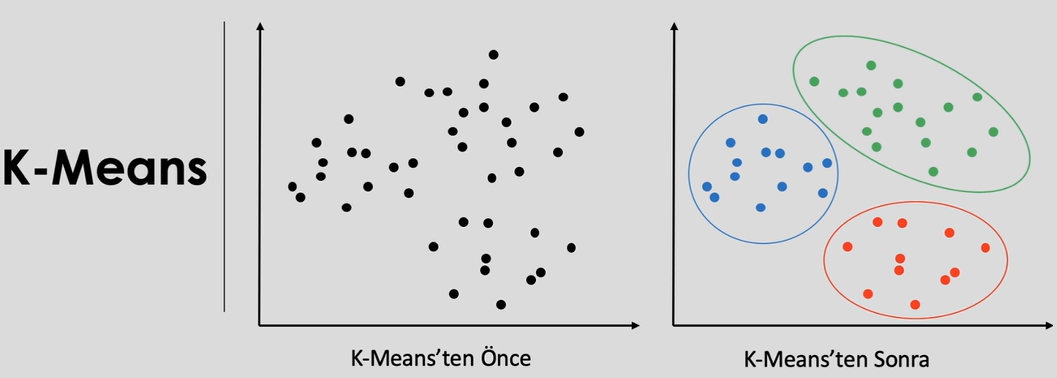

Resimde de görülebileceği üzere, gruplar kendi içerisinde homojen, diğer gruplara göre heterojendir. K-Means ise burada, başlangıçta karışık halde bulunan her bir grubu kendi içerisinde kümelemiştir.

Unsupervised Learning'in classification problems'dan tek farkı, bağımlı değişkene sahip olmayan veriler üzerinde uygulanıyor oluşudur. Aslında aynı şeyler fakat bunda, classification problemste incelediğimiz diabet olmuş mu olmamış mı verisetindeki 1 ve 0 lar yoktur, burada bağımsız değişkenler incelenerek gurplandırma yapılır.

Hemen bu bölümden önce incelemiş olduğumuz 3 bölüm olan doğrusal regresyon, doğrusal olmayan regresyon ve sınıflandırma problemleri, supervised learning'e örnektir, çünkü o zaman elimizde bağımlı değişkenimiz vardı.

K-Means adımları:

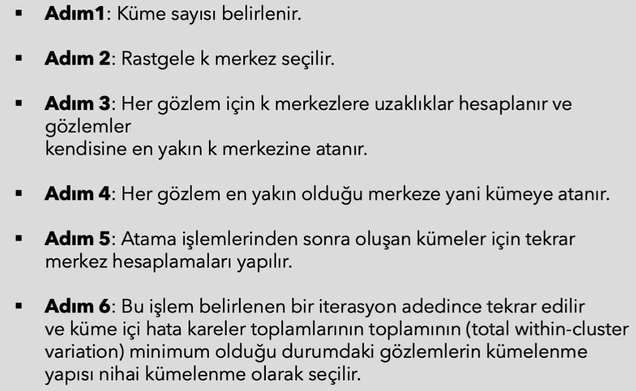

K-Means ve hiyerarşik segmentasayon çalışmalarında her zaman göz önünde bulundurmamız gereken bir şey var: İş Bilgisi. Yani çalışıyor olduğumuz alanın uzmanının görüşü önem arz etmektedir, çünkü oluşturacağımız segmentlere, çalışıyor olduğumuz alanda uzman birisinin gelip de bu veriyi bu kümeye koymuşsunuz ancak şu kümede olsa daha iyi olur çünkü şu şu sebeplerle diyebilir. Bu sebeple, oluşturduğumuz nihai kümelemeyi iş bilgisine sahip bir uzmana danışmak en sağlıklısı olacaktır

## K-Means Uygulama

In [1]:
from warnings import filterwarnings
filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as sp
from sklearn.cluster import KMeans

In [2]:
# verisetimize dayanarak söyleyebiliriz ki amacımız şu: verimide amerikadaki suçlar var, bunları eyaletlere göre kümelek istiyoruz
# oluşturacağımız bu kümelere göre eyaletlere bazı muamelelerde bulunmak istiyoruz.
# örneğin eyaletlerin suçlarına göre eyaletler özelinde yaptırım kararları vb
# yani elimizdeki veri, amerikadaki suçları gösteriyor fakat eyalet ayrımı olmadan, eyalet bazında çıkarım yapamacağımız halde bu veri. Biz bunu
# eyalet bazında düzenleyeceğiz ve her eyaletin kronik problemlerini ortaya çıkarmış olacağız K-means sayesinde

In [3]:
df = pd.read_csv("USArrests.csv").copy()
df

,Unnamed: 0,Murder,Assault,UrbanPop,Rape
0,Alabama,13.2,236,58,21.2
1,Alaska,10.0,263,48,44.5
2,Arizona,8.1,294,80,31.0
3,Arkansas,8.8,190,50,19.5
4,California,9.0,276,91,40.6
5,Colorado,7.9,204,78,38.7
6,Connecticut,3.3,110,77,11.1
7,Delaware,5.9,238,72,15.8
8,Florida,15.4,335,80,31.9
9,Georgia,17.4,211,60,25.8


In [12]:
df.index = df.iloc[:,0] # indexleri al, indexe denk gelen 1.sütun olan eyaletlerle değiştir. yani index yerine eyaletler olsun

In [14]:
df

,Unnamed: 0,Murder,Assault,UrbanPop,Rape
Unnamed: 0,,,,,
Alabama,Alabama,13.2,236,58,21.2
Alaska,Alaska,10.0,263,48,44.5
Arizona,Arizona,8.1,294,80,31.0
Arkansas,Arkansas,8.8,190,50,19.5
California,California,9.0,276,91,40.6
Colorado,Colorado,7.9,204,78,38.7
Connecticut,Connecticut,3.3,110,77,11.1
Delaware,Delaware,5.9,238,72,15.8
Florida,Florida,15.4,335,80,31.9


In [16]:
df = df.iloc[:, 1:5]
df.index.name = None
df

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6
Colorado,7.9,204,78,38.7
Connecticut,3.3,110,77,11.1
Delaware,5.9,238,72,15.8
Florida,15.4,335,80,31.9
Georgia,17.4,211,60,25.8


In [18]:
df.isnull().sum() # herhangi bir eksik veri var mı?

Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

In [20]:
df.info() # sütunlarla alakalı bilgi alalım

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Alabama to Wyoming
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 2.0+ KB


In [22]:
df.describe().T # verisetimizin betimsel istatistiklerine bakalım

,count,mean,std,min,25%,50%,75%,max
Murder,50.0,7.788,4.355510,0.8,4.075,7.25,11.250,17.4
Assault,50.0,170.760,83.337661,45.0,109.000,159.00,249.000,337.0
UrbanPop,50.0,65.540,14.474763,32.0,54.500,66.00,77.750,91.0
Rape,50.0,21.232,9.366385,7.3,15.075,20.10,26.175,46.0


## K-Means Model ve Görsel Oluşturma

In [26]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)

In [28]:
?kmeans

Type:        KMeans
String form: KMeans(n_clusters=4)
File:        c:\users\since\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py
Docstring:  
K-Means clustering.

Read more in the :ref:`User Guide <k_means>`.

Parameters
----------

n_clusters : int, default=8
    The number of clusters to form as well as the number of
    centroids to generate.

init : {'k-means++', 'random'}, callable or array-like of shape             (n_clusters, n_features), default='k-means++'
    Method for initialization:

    'k-means++' : selects initial cluster centroids using sampling based on
    an empirical probability distribution of the points' contribution to the
    overall inertia. This technique speeds up convergence. The algorithm
    implemented is "greedy k-means++". It differs from the vanilla k-means++
    by making several trials at each sampling step and choosing the best centroid
    among them.

    'random': choose `n_clusters` observations (rows) at random from data
    for the i

In [30]:
k_fit = kmeans.fit(df)

In [31]:
k_fit.n_clusters

4

In [32]:
k_fit.cluster_centers_ # cluster sayısını 4 verdiğimizden dolayı 4 tane küme olacak, onların merkezlerini ifade ediyor burası satırlar halinde

array([[  5.59      , 112.4       ,  65.6       ,  17.27      ],
       [ 11.8125    , 272.5625    ,  68.3125    ,  28.375     ],
       [  8.21428571, 173.28571429,  70.64285714,  22.84285714],
       [  2.95      ,  62.7       ,  53.9       ,  11.51      ]])

In [33]:
k_fit.labels_ # her bir satırın(yani eyaletin, çünkü index=eyalet idi), hangi etiketi aldığını bu şekilde görebiliriz

array([1, 1, 1, 2, 1, 2, 0, 1, 1, 2, 3, 0, 1, 0, 3, 0, 0, 1, 3, 1, 2, 1,
       3, 1, 2, 0, 0, 1, 3, 2, 1, 1, 1, 3, 0, 2, 2, 0, 2, 1, 3, 2, 2, 0,
       3, 2, 2, 3, 3, 2])

### Clusterları görselleştirme

In [35]:
kmeans = KMeans(n_clusters=2)
k_fit = kmeans.fit(df)

In [36]:
kumeler = k_fit.labels_

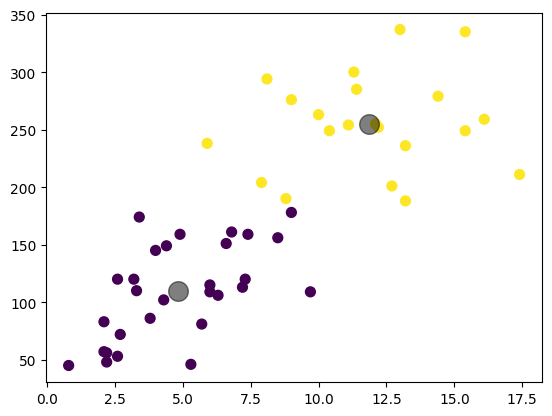

In [41]:
plt.scatter(df.iloc[:,0], df.iloc[:,1], c=kumeler, s=50, cmap="viridis")

merkezler = k_fit.cluster_centers_
plt.scatter(merkezler[:,0], merkezler[:,1], c = "black", s = 200, alpha = 0.5);

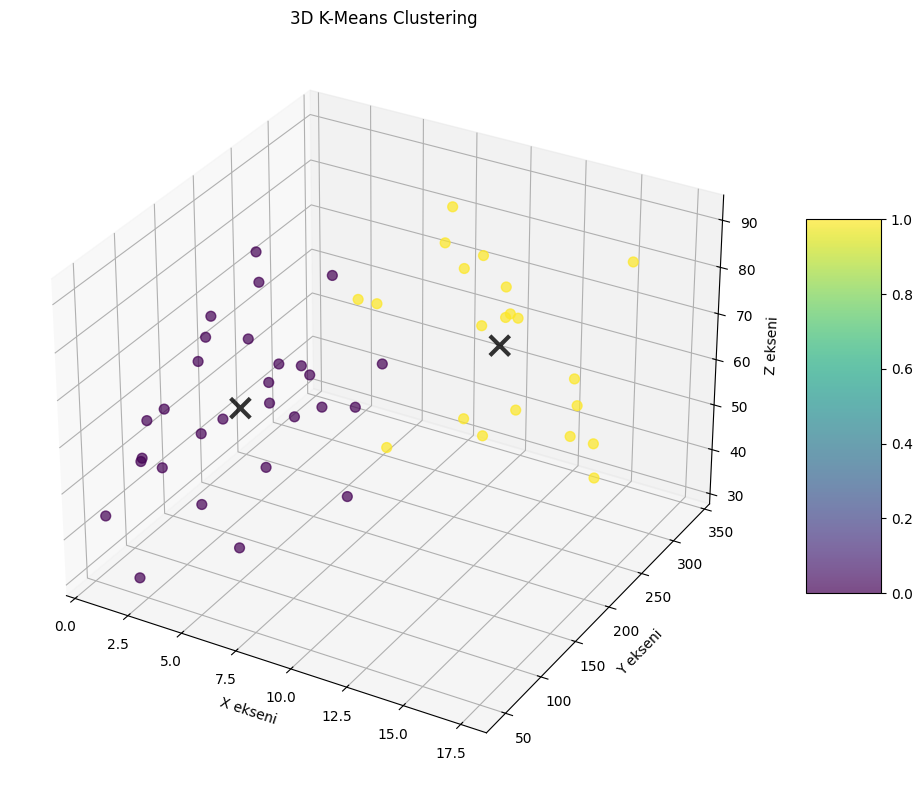

In [42]:
# bir önceki grafiği 3 boyutlu görüntüleyebileceğimiz kod:

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 3D figür oluştur
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Veri noktalarını 3D olarak çiz (ilk 3 sütunu kullanarak)
scatter = ax.scatter(df.iloc[:,0], df.iloc[:,1], df.iloc[:,2], 
                    c=kumeler, s=50, cmap="viridis", alpha=0.7)

# Küme merkezlerini çiz
merkezler = k_fit.cluster_centers_
ax.scatter(merkezler[:,0], merkezler[:,1], merkezler[:,2], 
           c="black", s=200, alpha=0.8, marker='x', linewidths=3)

# Eksen etiketleri
ax.set_xlabel('X ekseni')
ax.set_ylabel('Y ekseni')
ax.set_zlabel('Z ekseni')

# Başlık
ax.set_title('3D K-Means Clustering')

# Renk çubuğu ekle
plt.colorbar(scatter, ax=ax, shrink=0.5, aspect=5)

# Göster
plt.tight_layout()
plt.show()

In [43]:
# kumeler ve gozlem birimleri: hangi clusterde hangi eyalet var?

In [44]:
kmeans = KMeans(n_clusters=3)
k_fit = kmeans.fit(df)
kumeler = k_fit.labels_

In [45]:
pd.DataFrame({"Eyaletler": df.index, "Kumeler": kumeler})[:10] # hangi eyalet hangi kümeye dahil bunu görüyoruz

,Eyaletler,Kumeler
0,Alabama,0
1,Alaska,0
2,Arizona,0
3,Arkansas,2
4,California,0
5,Colorado,2
6,Connecticut,1
7,Delaware,0
8,Florida,0
9,Georgia,2


In [48]:
# bu şekilde dataframe'imize de onu ekleyebiliriz
df["Eyaletin Kümesi"]=kumeler
df

,Murder,Assault,UrbanPop,Rape,Eyaletin Kümesi
Alabama,13.2,236,58,21.2,0
Alaska,10.0,263,48,44.5,0
Arizona,8.1,294,80,31.0,0
Arkansas,8.8,190,50,19.5,2
California,9.0,276,91,40.6,0
Colorado,7.9,204,78,38.7,2
Connecticut,3.3,110,77,11.1,1
Delaware,5.9,238,72,15.8,0
Florida,15.4,335,80,31.9,0
Georgia,17.4,211,60,25.8,2


In [73]:
df = df.drop('Eyaletin Kümesi', axis=1)

## K-Means Model Tuning : Optimum cluster(küme) sayısının bulunması

In [76]:
# Bizim için kümeler içi benzerliğin maksimum, kümeler arası benzerliğin ise minimum olması gerekli
# Bunun yapılma yollarından biri: matematiksel olarak, 
# her bir gözlem biriminin merkeze olan uzaklığının(distance'ının) hata kareler ortalamasına bakarız 
# (daha önceki hata kareler ile aynı ancak burada bu hata kareler ortalaması distance olarak kullanılıyor.) 
# en yakın olanlar birlikte kümelenmiş olur
# Bunu yapmak için kullanılan yöntemler:
# 1) Elbow Method
# 2) Silhouette Method
# 3) Gap Statistic
# Biz burada sık kullanılan Elbow yöntemini göreceğiz

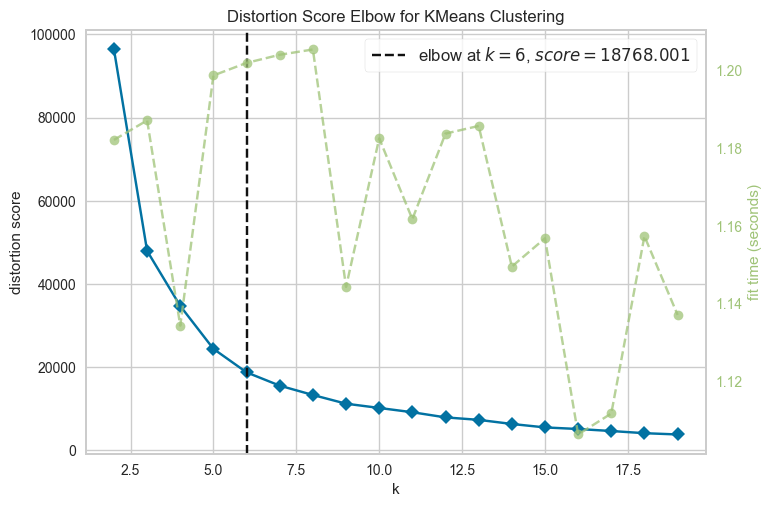

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [78]:
#!pip install yellowbrick
from yellowbrick.cluster import KElbowVisualizer
kmeans = KMeans()
visualizer = KElbowVisualizer(kmeans, k=(2,20)) # 2'den 20'ye kadar küme sayılarını dene, ve elde ettiğin sonuçları görselleştir
visualizer.fit(df)
visualizer.poof()

In [83]:
# grafiği yorumlayacak olursak: 

# mavi eğri: mesafe skorunu gösteriyor(az olması iyi bir şey. mesafe az demek küme merkezine)

# yeşil eğri: fit süresi

# x ekseni: küme sayısı

# özet: küme sayısı 6 iken en optimum mesafe sonucunu almışız, 6 küme kullan bu veriseti için diyor grafik

# not: küme sayısı arttıkça y eksenin solundaki distribution score'un azalması da mantıklı çünkü en sonunda gözlem sayısı kadar küme olursa,
# merkez artık gözleme eşit mesafede, üst üste olacağı için mesafe de sıfır olur.

In [85]:
kmeans = KMeans(n_clusters=6)
k_fit = kmeans.fit(df)
kumeler = k_fit.labels_

In [86]:
pd.DataFrame({"Eyaletler":df.index, "Kumeler":kumeler})

,Eyaletler,Kumeler
0,Alabama,1
1,Alaska,1
2,Arizona,4
3,Arkansas,5
4,California,1
5,Colorado,5
6,Connecticut,2
7,Delaware,1
8,Florida,4
9,Georgia,5


# Hierarchical Clustering (Hiyerarşik Kümeleme)

Amaç: K-Means'de olduğu gibi, gözlemleri birbirlerine olan benzerliklerine göre ayırmaktır.

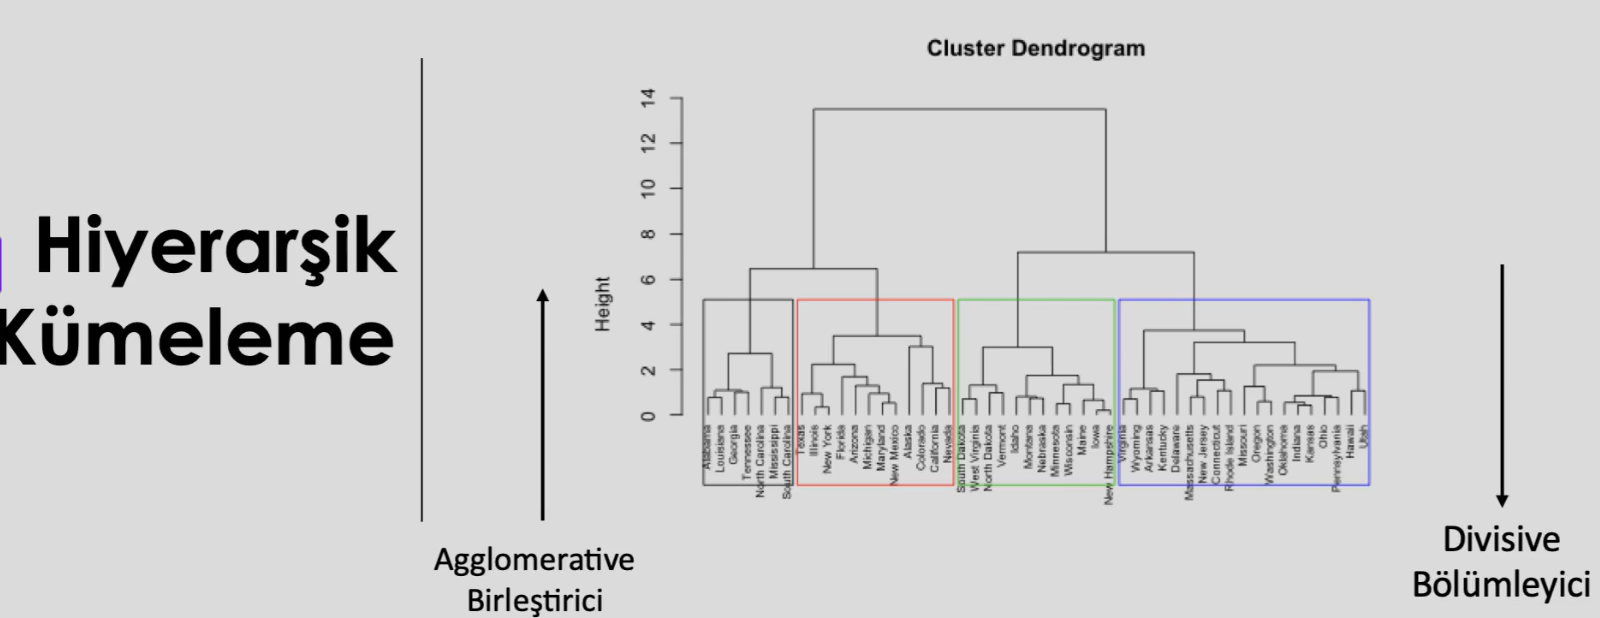

Resimden de görülebileceği üzere, temelde 4 kümeye ayrılan veriseti, daha da detaylara inildiğinde daha fazla kümeye ayrılmıştır. 

Hiyerarşik kelimesinin neden kullanıldığı resimden anlaşılabilmektedir. Başlangıçta bir arada tek kümede bulunan veriseti, önce 2'ye bölünür, onun altında da 2'ye bölünür ve bu şekilde devam eder. 

Hiyerarşik kümeleme 2'ye ayrılır:
1) Agglomerative (Birleştirici)
2) Divisive (Bölümleyici)

Agglomerative'de ise Divisive'de yapılan işlemin tam tersi gerçekleşir. Alttan alınan gözlem birimleri birleştirile birleştirile tek küme haline getirilir.

Agglomerative'de **benzerliklerine göre** **birleştirile** birleştirile en yukarıya kadar çıkılırken, Divisive'de **benzemezliklerine göre** birbirinden **ayrılır**

Hiyerarşik ve Hiyerarşik olmayan yöntemlerin farkları:
* Hiyerarşik yöntemlerde küme sayısına Dendogram sonuçlarına bakılarak karar verilir.
* Hiyerarşik olmayan yöntemlerde ise küme sayısı, **uygulama yapılmadan önce** belirlenir. (en temel fark bu)
* Hiyerarşik yöntemlerde veriseti, **gözlemler ve değişkenler** bazında kümeleme işlemine sokulabilirken
* Hiyerarşik olmayan yöntemlerde **sadece gözlemlerin** kümelenmesi mümkündür

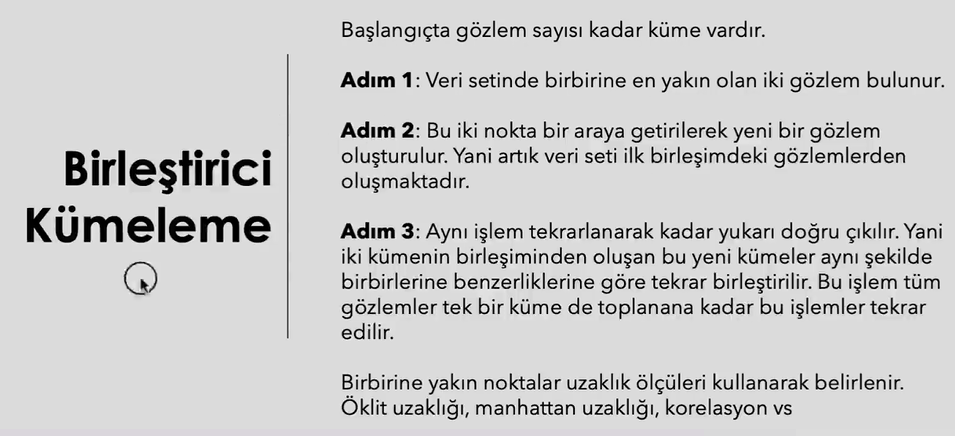

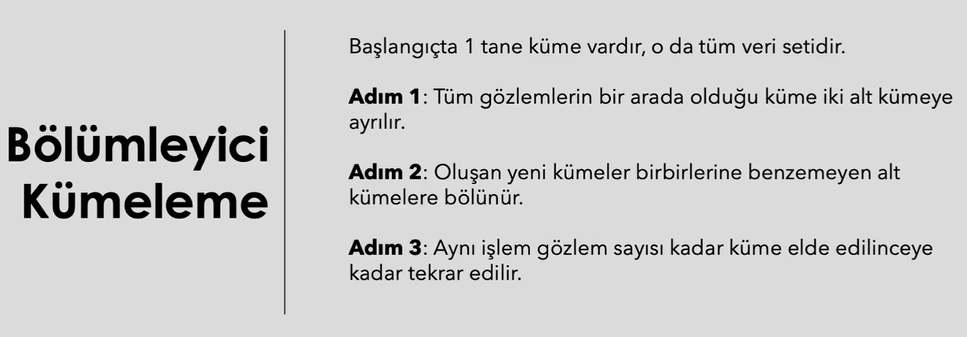

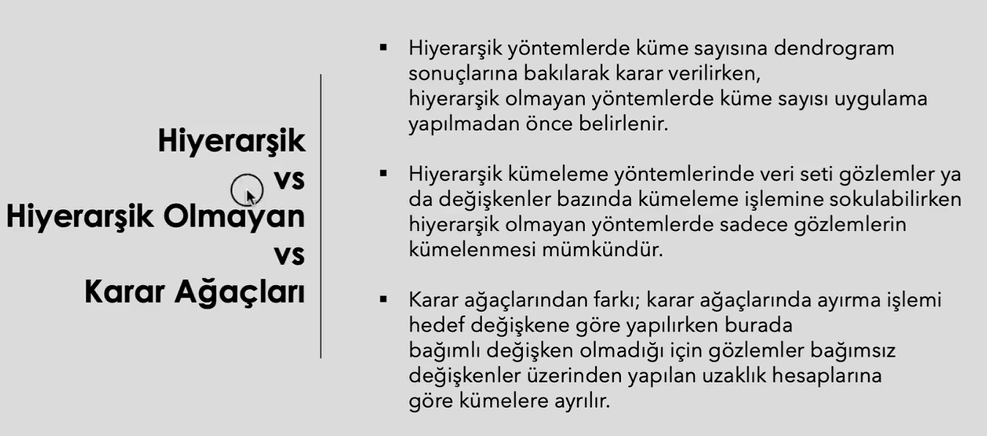

## Hiyerarşik Clustering - Uygulama

In [7]:
df = pd.read_csv("USArrests.csv").copy()
df.index = df.iloc[:,0]
df = df.iloc[:,1:5]
df.index.name = None
df.head()

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [9]:
# Hierarchical Clustering kullanabilmek için bazı metodlar var, onları indireceğiz şimdi: 
from scipy.cluster.hierarchy import linkage
hc_complete = linkage(df, "complete")
hc_average = linkage(df, "average")
hc_single = linkage(df, "single")

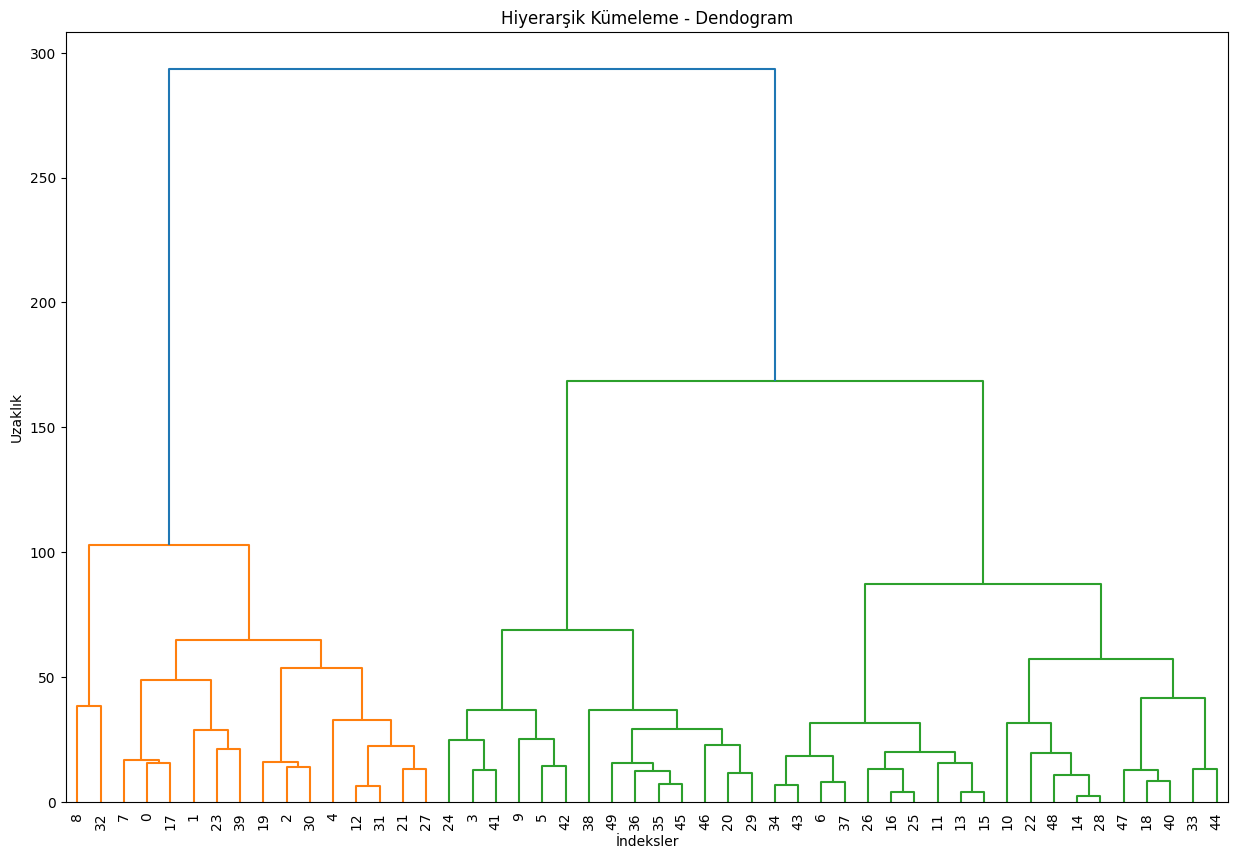

In [11]:
# dendogramımızı bu şekilde görebiliriz

from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(15, 10))
plt.title('Hiyerarşik Kümeleme - Dendogram')
plt.xlabel('İndeksler')
plt.ylabel('Uzaklık')
dendrogram(
    hc_complete,
    leaf_font_size=10
);

# en sondaki rakamlar index numarlarını söylüyor

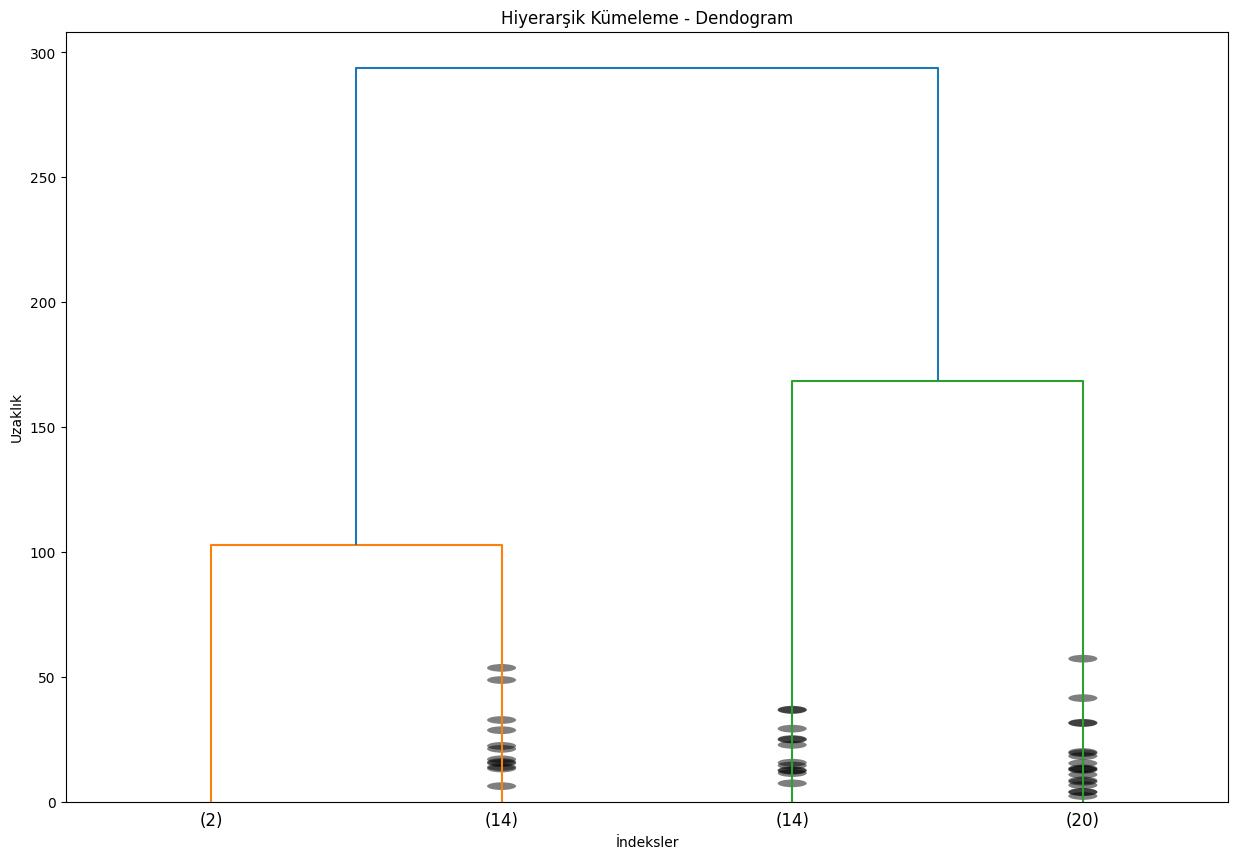

In [12]:
# bir öncekinin aynısı fakat, son 4 yapraklı halini getir dedik. 

from scipy.cluster.hierarchy import dendrogram

plt.figure(figsize=(15, 10))
plt.title('Hiyerarşik Kümeleme - Dendogram')
plt.xlabel('İndeksler')
plt.ylabel('Uzaklık')
dendrogram(
    hc_complete,
    truncate_mode="lastp",
    p=4,
    show_contracted=True
);

# en sondaki rakamlar da o leafte kaçtane eleman olduğunu gösteriyor

## Optimum Cluster(Küme) Sayısı

In [14]:
from sklearn.cluster import AgglomerativeClustering
cluster = AgglomerativeClustering(n_clusters=4, affinity = "euclidean", linkage="ward")

cluster.fit_predict(df)

array([0, 0, 0, 2, 0, 2, 3, 0, 0, 2, 1, 3, 0, 3, 1, 3, 3, 0, 1, 0, 2, 0,
       1, 0, 2, 3, 3, 0, 1, 2, 0, 0, 0, 1, 3, 2, 2, 3, 2, 0, 1, 2, 2, 3,
       1, 2, 2, 1, 1, 2], dtype=int64)

In [15]:
pd.DataFrame({"Eyaletler":df.index, "Kumeler":cluster.fit_predict(df)})

,Eyaletler,Kumeler
0,Alabama,0
1,Alaska,0
2,Arizona,0
3,Arkansas,2
4,California,0
5,Colorado,2
6,Connecticut,3
7,Delaware,0
8,Florida,0
9,Georgia,2


In [16]:
df["Eyalet Kümeleri"] = cluster.fit_predict(df)
df

,Murder,Assault,UrbanPop,Rape,Eyalet Kümeleri
Alabama,13.2,236,58,21.2,0
Alaska,10.0,263,48,44.5,0
Arizona,8.1,294,80,31.0,0
Arkansas,8.8,190,50,19.5,2
California,9.0,276,91,40.6,0
Colorado,7.9,204,78,38.7,2
Connecticut,3.3,110,77,11.1,3
Delaware,5.9,238,72,15.8,0
Florida,15.4,335,80,31.9,0
Georgia,17.4,211,60,25.8,2


# PCA - Principal Component Analysis (Temel Bileşen Analizi)

Amaç: Çok değişkenli bir verinin daha az değişken ile temsiliyetini sağlamaktır. 

Diğer bir ifade ile; küçük miktarda bilgi kaybını göze alıp, değişken boyutunu azaltmaktır.

PCA ile Doğrusal regresyonda tanışmıştık, Bağımlı değişkenin olmadığı bu Unsupervised bölümünde de karşımıza çıkmış oldu.

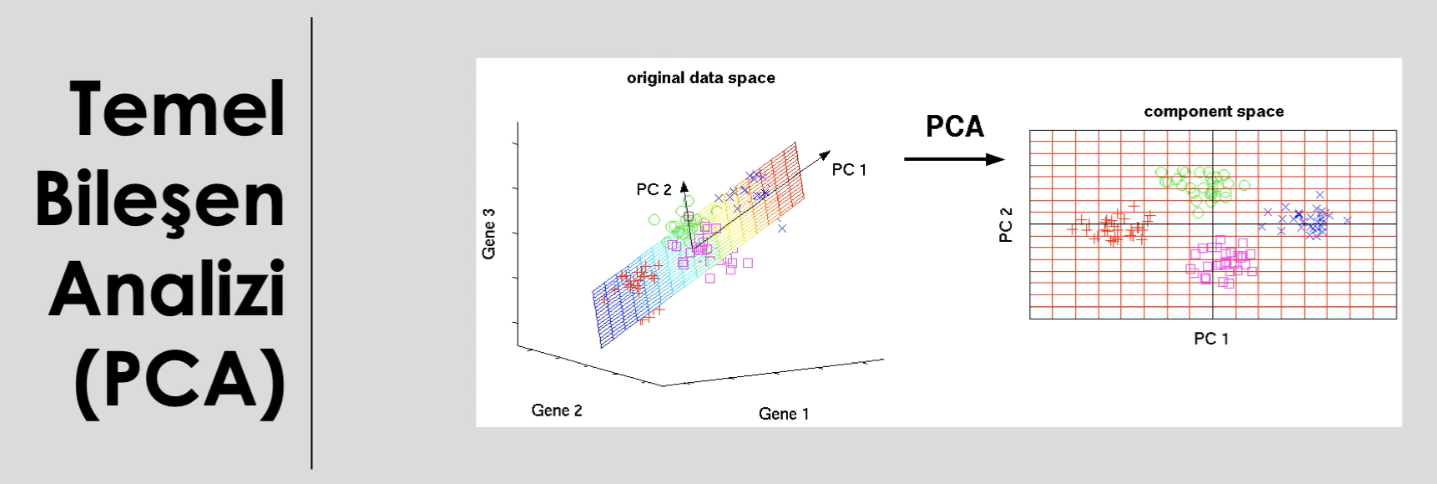

Burada da görebileceğiniz üzere, 3 değişkenli(Gen1, Gen2 ve Gen3) olan veriseti, 2 değişkenli(PC1 ve PC2) olarak indirgenmiş.

Kovaryans veya kolerasyon matrislerinin öz değer ve öz vektörlerinin bulunması işidir.

PCA'in teknik ifadesi: Değişken gruplarının varyanslarını ifade eden öz değerler ile verisetindeki değişkenler gruplandırılır. Gruplar arasında en fazla varyansa sahip gruplar en önemli gruplardır, bunlara biz asal bileşenler deriz.

## PCA - Uygulama

In [32]:
df = pd.read_csv("USArrests.csv").copy()
df.index = df.iloc[:,0]
df = df.iloc[:,1:5]
df.index.name = None
df.head()

,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [37]:
# PCA'i uygulayabilmek için değişkenleri standartlaştırma işlemini yapacağız:

from sklearn.preprocessing import StandardScaler

df = StandardScaler().fit_transform(df)

df[0:5, 0:5]

array([[ 1.25517927,  0.79078716, -0.52619514, -0.00345116],
       [ 0.51301858,  1.11805959, -1.22406668,  2.50942392],
       [ 0.07236067,  1.49381682,  1.00912225,  1.05346626],
       [ 0.23470832,  0.23321191, -1.08449238, -0.18679398],
       [ 0.28109336,  1.2756352 ,  1.77678094,  2.08881393]])

In [43]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_fit = pca.fit_transform(df)
pca_fit

array([[ 0.98556588,  1.13339238],
       [ 1.95013775,  1.07321326],
       [ 1.76316354, -0.74595678],
       [-0.14142029,  1.11979678],
       [ 2.52398013, -1.54293399],
       [ 1.51456286, -0.98755509],
       [-1.35864746, -1.08892789],
       [ 0.04770931, -0.32535892],
       [ 3.01304227,  0.03922851],
       [ 1.63928304,  1.2789424 ],
       [-0.91265715, -1.57046001],
       [-1.63979985,  0.21097292],
       [ 1.37891072, -0.68184119],
       [-0.50546136, -0.15156254],
       [-2.25364607, -0.10405407],
       [-0.79688112, -0.2701647 ],
       [-0.75085907,  0.95844029],
       [ 1.56481798,  0.87105466],
       [-2.39682949,  0.37639158],
       [ 1.76336939,  0.42765519],
       [-0.48616629, -1.4744965 ],
       [ 2.10844115, -0.15539682],
       [-1.69268181, -0.63226125],
       [ 0.99649446,  2.39379599],
       [ 0.69678733, -0.26335479],
       [-1.18545191,  0.53687437],
       [-1.26563654, -0.19395373],
       [ 2.87439454, -0.7756002 ],
       [-2.38391541,

In [47]:
bilesen_df = pd.DataFrame(data=pca_fit, columns=["birinci_bilesen","ikinci_bilesen"])
bilesen_df

,birinci_bilesen,ikinci_bilesen
0,0.985566,1.133392
1,1.950138,1.073213
2,1.763164,-0.745957
3,-0.141420,1.119797
4,2.523980,-1.542934
5,1.514563,-0.987555
6,-1.358647,-1.088928
7,0.047709,-0.325359
8,3.013042,0.039229
9,1.639283,1.278942


Bir önceki satırda standartlaştırılmış dataframe'imizi görüyoruz: 

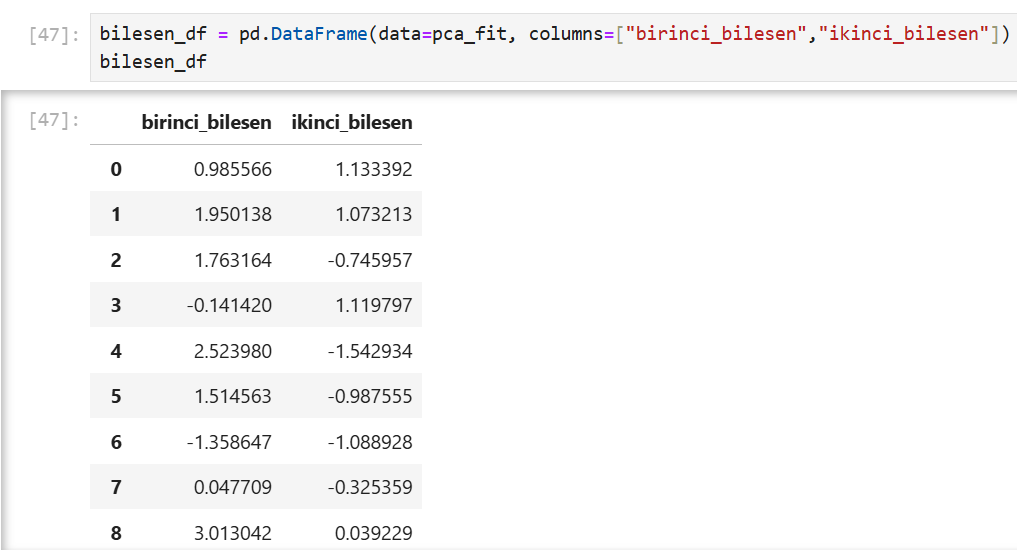

Burada ise dataframe'in baştaki halini görüyoruz:

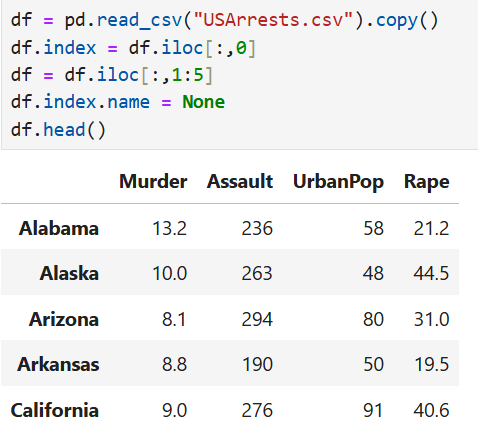

Aslında aynı şeyler fakat standartlaştırılmış pca versiyonunda, en baştaki 4 değişkenli halini 2 değişkende temsil etmiş olduk, standartlaştırma yapmış olduk.

In [69]:
pca.explained_variance_ratio_ 

# burada, pca ile standartlaştırılan dataframe'in orijinal olanı varyans olarak ne kadar oranda temsil ettiğini görebiliyoruz
# standartlaştırılmış dataframe'de ki birinci_bilesen sütunu, %62 ile temsil sağlıyorken ikinci_bilesen sütunu ise %24 ile temsiliyet sağlanıyor
# kümülatif olarak bunları topladığımızda %86 olarak temsiliyet elde ettiğimizi görüyoruz ve bu da gayet iyi bir oran
# eğer yukarıda pca = PCA(n_components=2) kısmıdna 3 yapsaydık, ([0.62006039, 0.24744129, 0.089...]) gibi bir şey aldığımızı görecektik,
# yani bileşen sayısını artırdıkça yol alamıyorsun. Genelde 2-3 bileşen mevcut değişkenliği(variance) açıklıyor olacaktır

array([0.62006039, 0.24744129])

## PCA - Model Tuning

In [72]:
pca = PCA() # bu sefer n_components sayısını(bileşen sayısını) söylemeden oluşturuyorum
pca_fit = pca.fit(df)

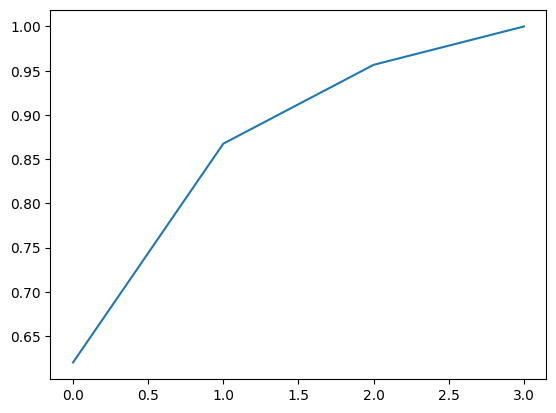

In [80]:
plt.plot(np.cumsum(pca.explained_variance_ratio_ )) 

# burada işte bileşen sayılarının verimliliklerini görüp kaç tane kullanacağımıza karar verebilirz
# grafikten şunu anlıyoruz: eğer 2 bileşen kullanırsak verisetindeki değişkenliği(variance) %95 oranında açıklayabilirim
# yani az önce biz doğru yapmışız